In [72]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field
from langchain_ollama import ChatOllama 
import operator
from langchain_core.messages import SystemMessage, HumanMessage

In [75]:
# state

class TwitterState(TypedDict):

    topic : str
    tweet : str
    evaluation : Literal['approved','needs_improvement']
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]


In [76]:
# to get structured output from evaluator llm

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [77]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [78]:
generator_llm = ChatOllama(model='llama3.2:3b')
evaluator_llm = ChatOllama(model='llama3.2:3b')
optimizer_llm = ChatOllama(model='llama3.2:3b')

In [79]:
def generate_tweet(state: TwitterState):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    # send generator_llm
    response = generator_llm.invoke(messages).content

    # return response
    return {'tweet': response, 'tweet_history': [response]}

In [81]:
def evaluate_tweet(state: TwitterState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}


In [82]:
def optimize_tweet(state: TwitterState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [83]:
def route_evaluation(state: TwitterState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

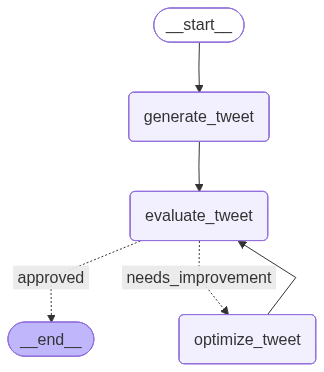

In [89]:
# graph

graph = StateGraph(TwitterState)

# nodes

graph.add_node('generate_tweet', generate_tweet)
graph.add_node('evaluate_tweet', evaluate_tweet)
graph.add_node('optimize_tweet', optimize_tweet)

# edges
graph.add_edge(START, 'generate_tweet')
graph.add_edge('generate_tweet', 'evaluate_tweet')

graph.add_conditional_edges('evaluate_tweet', route_evaluation, {'approved': END, 'needs_improvement': 'optimize_tweet'})
graph.add_edge('optimize_tweet', 'evaluate_tweet')

# compile
workflow = graph.compile()
workflow


In [92]:
initial_state = {
    "topic": "The game of politics in india and the joke of citizens",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)
result

{'topic': 'The game of politics in india and the joke of citizens',
 'tweet': '"Politics in India is like a masala movie - drama, twists, and more twists. Except the hero doesn\'t save the day, just tweets about it. Meanwhile, we\'re over here thinking \'vishwas hai\' (trust) is just a synonym for \'not paying attention to what\'s happening\' #IndianPolitics"',
 'evaluation': 'approved',
 'feedback': "This tweet is an original take on a relatable topic, leveraging a well-known Indian cultural reference to poke fun at politics. The humor is dry and observational, making it likely to elicit a chuckle from many readers. The format is concise and punchy, with a clear setup and unexpected twist. The potential for virality lies in its universality and the likelihood that many people can relate to the sentiment. A minor suggestion could be to consider adding a visually appealing image or meme to further amplify the tweet's impact.",
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['"P